# ML Assignment 1 — Polynomial Regression

Complete workflow for VAR1 and VAR2.

In [1]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\kvina\AppData\Local\Programs\Python\Python313\python.exe
3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]


In [2]:
import sys
import subprocess
import importlib.util

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
}

missing = [
    package
    for module, package in required_packages.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    print("Missing packages:", ", ".join(missing))
    print("Installing into:", sys.executable)
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", *missing
    ])
    print("Installation completed.")
else:
    print("All required packages are already installed.")

print("Python used by this notebook:")
print(sys.executable)


All required packages are already installed.
Python used by this notebook:
c:\Users\kvina\AppData\Local\Programs\Python\Python313\python.exe


In [3]:
# 1. Imports

from pathlib import Path
from itertools import combinations
import re
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

RANDOM_STATE = 42
N_SPLITS = 5

DATA_DIR = Path(r"C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026")

FIGURES_DIR = DATA_DIR / "figures"
OUTPUT_DIR = DATA_DIR / "outputs"

print("Python:", sys.executable)
print("Dataset folder:", DATA_DIR)
print("Dataset folder exists:", DATA_DIR.exists())

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "\nThe dataset folder was not found.\n"
        f"Expected exact folder:\n{DATA_DIR}\n\n"
        "Check that the folder exists and that the path is copied exactly."
    )

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Figures will be saved to:", FIGURES_DIR)
print("Prediction/output files will be saved to:", OUTPUT_DIR)


Python: c:\Users\kvina\AppData\Local\Programs\Python\Python313\python.exe
Dataset folder: C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026
Dataset folder exists: True
Figures will be saved to: C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026\figures
Prediction/output files will be saved to: C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026\outputs


## 1. Load datasets

In [4]:
# 2. Load datasets

csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"CSV files found directly inside DATA_DIR: {len(csv_files)}")
for p in csv_files:
    print(" -", p.name)

def find_one(filename_pattern):
    matches = sorted(DATA_DIR.glob(filename_pattern))
    if not matches:
        raise FileNotFoundError(
            f"Could not find a file matching '{filename_pattern}' inside:\n{DATA_DIR}\n\n"
            "Make sure the four assignment CSV files are in the exact dataset folder."
        )
    if len(matches) > 1:
        raise RuntimeError(
            f"More than one file matched '{filename_pattern}':\n"
            + "\n".join(str(p) for p in matches)
            + "\n\nPlease keep only the correct personalized dataset files."
        )
    return matches[0]

train_var1_path = find_one("*_train_var1.csv")
test_var1_path  = find_one("*_test_var1.csv")
train_var2_path = find_one("*_train_var2.csv")
test_var2_path  = find_one("*_test_var2.csv")

print("\nFiles selected:")
print("VAR1 train:", train_var1_path)
print("VAR1 test :", test_var1_path)
print("VAR2 train:", train_var2_path)
print("VAR2 test :", test_var2_path)

m = re.match(r"(.+)_train_var1\.csv$", train_var1_path.name, re.IGNORECASE)
if not m:
    raise ValueError(f"Unexpected VAR1 training filename: {train_var1_path.name}")



# Load the data.
train_var1 = pd.read_csv(train_var1_path)
test_var1 = pd.read_csv(test_var1_path)
train_var2 = pd.read_csv(train_var2_path)
test_var2 = pd.read_csv(test_var2_path)

print("\nShapes:")
print("VAR1 train:", train_var1.shape)
print("VAR1 test :", test_var1.shape)
print("VAR2 train:", train_var2.shape)
print("VAR2 test :", test_var2.shape)


CSV files found directly inside DATA_DIR: 4
 - IMT2023608_test_var1.csv
 - IMT2023608_test_var2.csv
 - IMT2023608_train_var1.csv
 - IMT2023608_train_var2.csv

Files selected:
VAR1 train: C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026\IMT2023608_train_var1.csv
VAR1 test : C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026\IMT2023608_test_var1.csv
VAR2 train: C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026\IMT2023608_train_var2.csv
VAR2 test : C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026\IMT2023608_test_var2.csv

Shapes:
VAR1 train: (1000, 7)
VAR1 test : (1000, 6)
VAR2 train: (1000, 4)
VAR2 test : (1000, 3)


In [5]:
# 3. Inspect data

datasets = {
    "VAR1 train": train_var1,
    "VAR1 test": test_var1,
    "VAR2 train": train_var2,
    "VAR2 test": test_var2,
}

for name, df in datasets.items():
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print("Columns:", list(df.columns))
    print("\nDtypes:")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isna().sum())
    print("Duplicate rows:", df.duplicated().sum())

if "y" not in train_var1.columns or "y" not in train_var2.columns:
    raise ValueError("Training data must contain target column 'y'.")

X_train_var1 = train_var1.drop(columns="y").copy()
y_train_var1 = train_var1["y"].copy()
X_test_var1 = test_var1.copy()

X_train_var2 = train_var2.drop(columns="y").copy()
y_train_var2 = train_var2["y"].copy()
X_test_var2 = test_var2.copy()

if list(X_train_var1.columns) != list(X_test_var1.columns):
    raise ValueError("VAR1 train/test feature columns do not match.")
if list(X_train_var2.columns) != list(X_test_var2.columns):
    raise ValueError("VAR2 train/test feature columns do not match.")

if X_train_var1.shape[1] != 6:
    raise ValueError(f"Expected 6 VAR1 features; found {X_train_var1.shape[1]}.")
if X_train_var2.shape[1] != 3:
    raise ValueError(f"Expected 3 VAR2 features; found {X_train_var2.shape[1]}.")

print("\nVAR1 features:", list(X_train_var1.columns))
print("VAR2 features:", list(X_train_var2.columns))


VAR1 train
Columns: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y']

Dtypes:
x1    float64
x2    float64
x3    float64
x4    float64
x5    float64
x6    float64
y     float64
dtype: object

Missing values:
x1    0
x2    0
x3    0
x4    0
x5    0
x6    0
y     0
dtype: int64
Duplicate rows: 0

VAR1 test
Columns: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

Dtypes:
x1    float64
x2    float64
x3    float64
x4    float64
x5    float64
x6    float64
dtype: object

Missing values:
x1    0
x2    0
x3    0
x4    0
x5    0
x6    0
dtype: int64
Duplicate rows: 4

VAR2 train
Columns: ['x1', 'x2', 'x3', 'y']

Dtypes:
x1    float64
x2    float64
x3    float64
y     float64
dtype: object

Missing values:
x1    0
x2    0
x3    0
y     0
dtype: int64
Duplicate rows: 0

VAR2 test
Columns: ['x1', 'x2', 'x3']

Dtypes:
x1    float64
x2    float64
x3    float64
dtype: object

Missing values:
x1    0
x2    0
x3    0
dtype: int64
Duplicate rows: 10

VAR1 features: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
VAR2 features: ['x

## 2. Inspect data

In [6]:
# 4. Summary statistics

def show_summary(df, title):
    print(title)
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "unique": df.nunique(),
        "mean": df.mean(numeric_only=True),
        "std": df.std(numeric_only=True),
        "min": df.min(numeric_only=True),
        "max": df.max(numeric_only=True),
    })
    display(summary)

show_summary(train_var1, "VAR1 TRAIN")
show_summary(train_var2, "VAR2 TRAIN")

target_stats = pd.DataFrame({
    "VAR1 y": y_train_var1.describe(),
    "VAR2 y": y_train_var2.describe()
})
print("Target statistics:")
display(target_stats)

def train_test_comparison(X_train, X_test, name):
    rows = []
    for col in X_train.columns:
        rows.append({
            "Feature": col,
            "Train mean": X_train[col].mean(),
            "Test mean": X_test[col].mean(),
            "Train std": X_train[col].std(),
            "Test std": X_test[col].std(),
            "Train min": X_train[col].min(),
            "Test min": X_test[col].min(),
            "Train max": X_train[col].max(),
            "Test max": X_test[col].max(),
        })
    print(name)
    result = pd.DataFrame(rows)
    display(result)
    return result

dist_var1 = train_test_comparison(X_train_var1, X_test_var1, "VAR1 train/test")
dist_var2 = train_test_comparison(X_train_var2, X_test_var2, "VAR2 train/test")

VAR1 TRAIN


,dtype,missing,unique,mean,std,min,max
x1,float64,0,702,-0.010380,0.711096,-1.000000,1.000000
x2,float64,0,667,-0.002748,0.734105,-1.000000,1.000000
x3,float64,0,683,0.006571,0.714126,-1.000000,1.000000
x4,float64,0,684,-0.043014,0.726304,-1.000000,1.000000
x5,float64,0,677,-0.028833,0.720551,-1.000000,1.000000
x6,float64,0,693,-0.022027,0.719142,-1.000000,1.000000
y,float64,0,1000,0.863407,3.393751,-11.430134,14.348763


VAR2 TRAIN


,dtype,missing,unique,mean,std,min,max
x1,float64,0,759,-0.003675,0.670663,-1.000000,1.000000
x2,float64,0,770,-0.003322,0.670059,-1.000000,1.000000
x3,float64,0,735,0.026051,0.685155,-1.000000,1.000000
y,float64,0,1000,2.164522,6.807967,-29.990306,29.842381


Target statistics:


,VAR1 y,VAR2 y
count,1000.000000,1000.000000
mean,0.863407,2.164522
std,3.393751,6.807967
min,-11.430134,-29.990306
25%,-1.027651,-0.718994
50%,0.652320,1.233014
75%,2.864891,5.051079
max,14.348763,29.842381


VAR1 train/test


,Feature,Train mean,Test mean,Train std,Test std,Train min,Test min,Train max,Test max
0,x1,-0.010380,0.000464,0.711096,0.823448,-1.000000,-1.000000,1.000000,1.000000
1,x2,-0.002748,0.014525,0.734105,0.813306,-1.000000,-1.000000,1.000000,1.000000
2,x3,0.006571,0.020631,0.714126,0.818035,-1.000000,-1.000000,1.000000,1.000000
3,x4,-0.043014,-0.021921,0.726304,0.804690,-1.000000,-1.000000,1.000000,1.000000
4,x5,-0.028833,-0.018489,0.720551,0.811250,-1.000000,-1.000000,1.000000,1.000000
5,x6,-0.022027,0.005745,0.719142,0.820905,-1.000000,-1.000000,1.000000,1.000000


VAR2 train/test


,Feature,Train mean,Test mean,Train std,Test std,Train min,Test min,Train max,Test max
0,x1,-0.003675,0.006900,0.670663,0.674114,-1.000000,-1.000000,1.000000,1.000000
1,x2,-0.003322,-0.012607,0.670059,0.687544,-1.000000,-1.000000,1.000000,1.000000
2,x3,0.026051,-0.001205,0.685155,0.673752,-1.000000,-1.000000,1.000000,1.000000


## 3. EDA

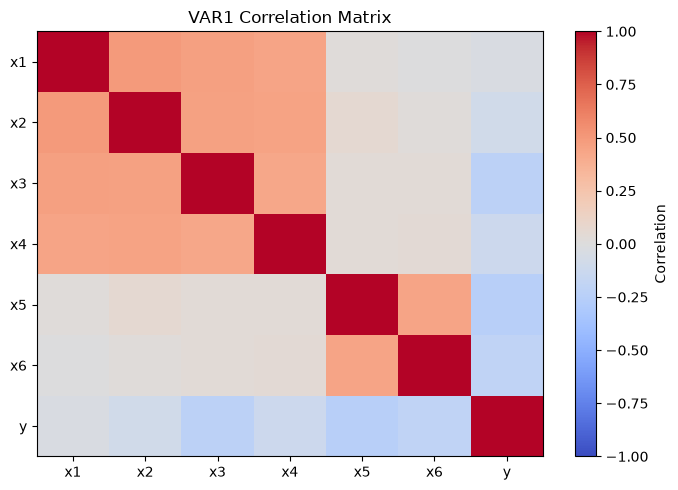

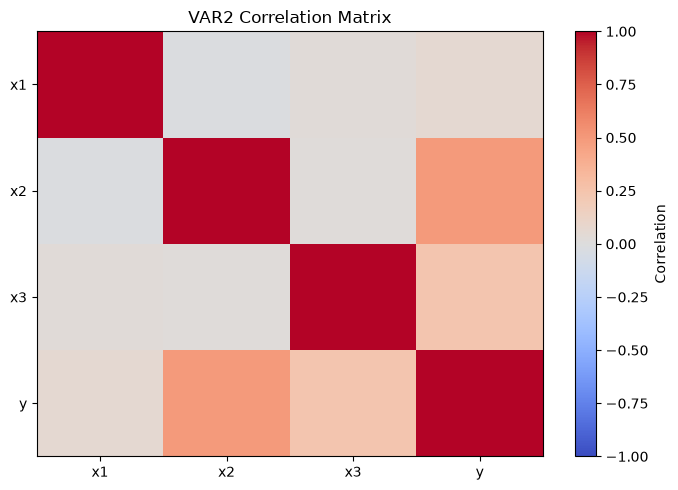

In [7]:
# 5. Correlation plots

def correlation_plot(df, problem):
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(7, 5))
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(label="Correlation")
    plt.xticks(range(len(corr.columns)), corr.columns)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title(f"{problem} Correlation Matrix")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{problem.lower()}_correlation.png", dpi=150)
    plt.show()

correlation_plot(train_var1, "VAR1")
correlation_plot(train_var2, "VAR2")

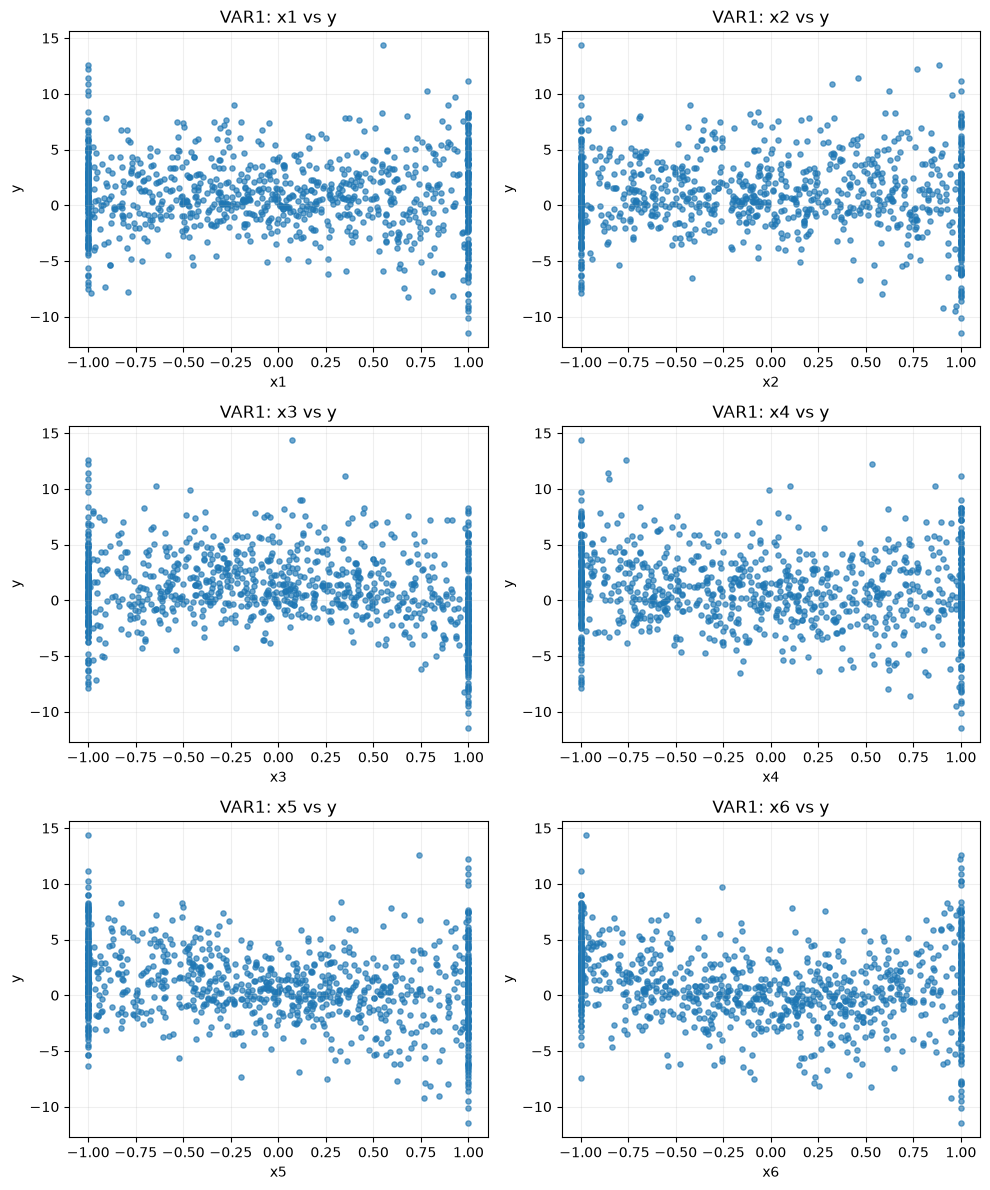

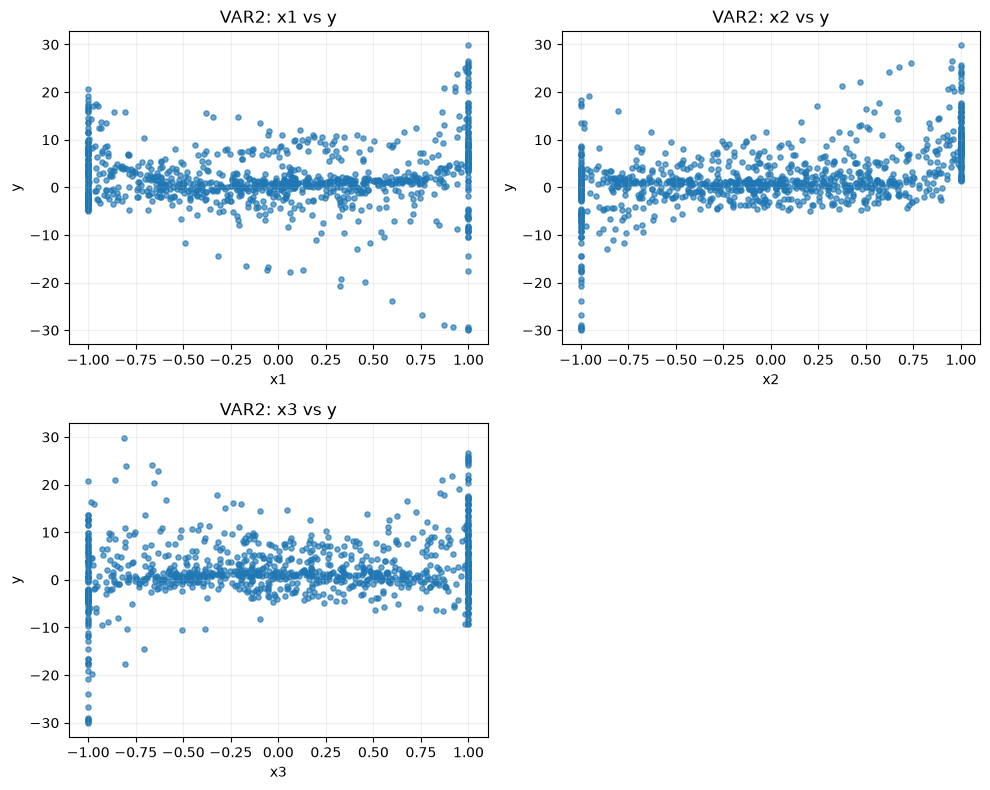

In [8]:
# 6. Feature-target plots

def feature_target_plot(X, y, problem):
    n = len(X.columns)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4*nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(X.columns):
        axes[i].scatter(X[col], y, s=14, alpha=0.65)
        axes[i].set_title(f"{problem}: {col} vs y")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("y")
        axes[i].grid(alpha=0.2)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{problem.lower()}_feature_target.png", dpi=150)
    plt.show()

feature_target_plot(X_train_var1, y_train_var1, "VAR1")
feature_target_plot(X_train_var2, y_train_var2, "VAR2")

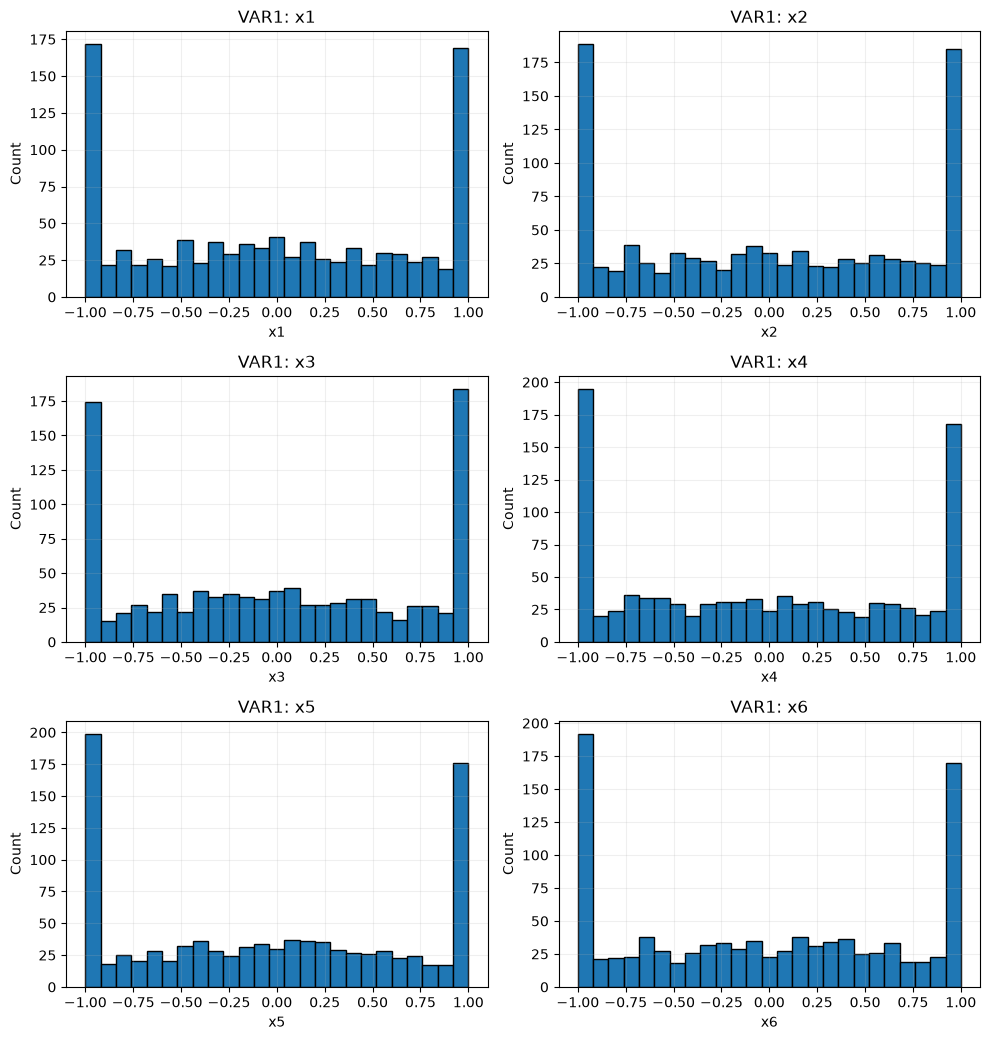

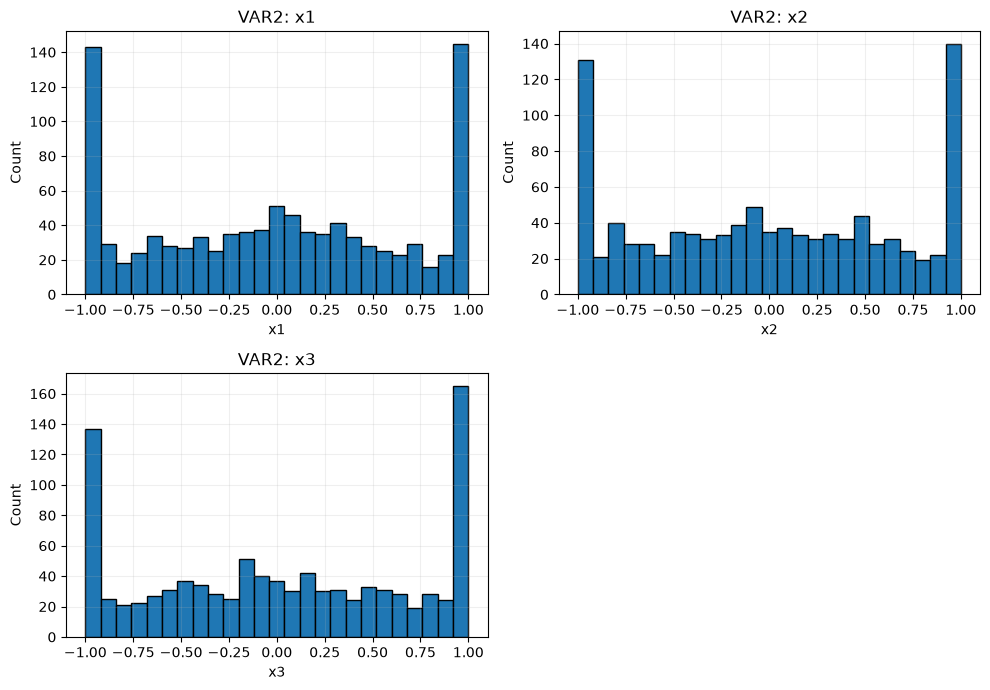

In [9]:
# 7. Feature distributions

def distribution_plot(X, problem):
    n = len(X.columns)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.5*nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(X.columns):
        axes[i].hist(X[col], bins=25, edgecolor="black")
        axes[i].set_title(f"{problem}: {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        axes[i].grid(alpha=0.2)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{problem.lower()}_distributions.png", dpi=150)
    plt.show()

distribution_plot(X_train_var1, "VAR1")
distribution_plot(X_train_var2, "VAR2")

## 4. Linear regression

In [10]:
# 8. Linear baseline

def evaluate_cv(model, X, y):
    scores = cross_validate(
        model, X, y, cv=cv,
        scoring={"mse": "neg_mean_squared_error", "r2": "r2"},
        return_train_score=True,
        n_jobs=-1
    )
    return {
        "CV MSE": -scores["test_mse"].mean(),
        "CV MSE std": scores["test_mse"].std(),
        "CV R2": scores["test_r2"].mean(),
        "CV R2 std": scores["test_r2"].std(),
        "Train MSE": -scores["train_mse"].mean(),
        "Train R2": scores["train_r2"].mean()
    }

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

baseline_var1 = evaluate_cv(linear_model, X_train_var1, y_train_var1)
baseline_var2 = evaluate_cv(linear_model, X_train_var2, y_train_var2)

baseline_results = pd.DataFrame([
    {"Problem":"VAR1", "Model":"Linear Regression", "Degree":1, "Features":"all", **baseline_var1},
    {"Problem":"VAR2", "Model":"Linear Regression", "Degree":1, "Features":"all", **baseline_var2}
])

display(baseline_results)

,Problem,Model,Degree,Features,CV MSE,CV MSE std,CV R2,CV R2 std,Train MSE,Train R2
0,VAR1,Linear Regression,1,all,10.312539,1.241140,0.097328,0.080091,10.053566,0.125891
1,VAR2,Linear Regression,1,all,32.488301,3.812859,0.295672,0.024073,32.187491,0.304672


## 5. Polynomial regression

In [11]:
# 9. Polynomial model

MAX_DEGREE_VAR1 = 10
MAX_DEGREE_VAR2 = 20

def make_poly_model(degree, estimator=None):
    if estimator is None:
        estimator = LinearRegression()
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("regressor", estimator)
    ])

def polynomial_term_count(n_features, degree):
    return math.comb(n_features + degree, degree) - 1

term_counts = pd.DataFrame({
    "Degree": range(1, MAX_DEGREE_VAR1 + 1),
    "VAR1 terms": [polynomial_term_count(6, d) for d in range(1, MAX_DEGREE_VAR1 + 1)]
})
print("VAR1 term counts:")
display(term_counts)

term_counts_var2 = pd.DataFrame({
    "Degree": range(1, MAX_DEGREE_VAR2 + 1),
    "VAR2 terms": [polynomial_term_count(3, d) for d in range(1, MAX_DEGREE_VAR2 + 1)]
})
print("VAR2 term counts:")
display(term_counts_var2)

VAR1 term counts:


,Degree,VAR1 terms
0,1,6
1,2,27
2,3,83
3,4,209
4,5,461
5,6,923
6,7,1715
7,8,3002
8,9,5004
9,10,8007


VAR2 term counts:


,Degree,VAR2 terms
0,1,3
1,2,9
2,3,19
3,4,34
4,5,55
5,6,83
6,7,119
7,8,164
8,9,219
9,10,285


In [12]:
# 10. Degree search

def search_all_degrees(X, y, problem, max_degree):
    rows = []
    for degree in range(1, max_degree + 1):
        scores = evaluate_cv(make_poly_model(degree), X, y)
        rows.append({
            "Problem": problem,
            "Degree": degree,
            "Features": "all",
            "Feature Count": X.shape[1],
            **scores
        })
        print(f"{problem} degree {degree:2d}: MSE={scores['CV MSE']:.6g}, R2={scores['CV R2']:.6f}")
    return pd.DataFrame(rows)

plain_var1 = search_all_degrees(X_train_var1, y_train_var1, "VAR1", MAX_DEGREE_VAR1)
plain_var2 = search_all_degrees(X_train_var2, y_train_var2, "VAR2", MAX_DEGREE_VAR2)
plain_results = pd.concat([plain_var1, plain_var2], ignore_index=True)

display(plain_results[["Problem","Degree","Features","CV MSE","CV MSE std","CV R2","CV R2 std"]])

VAR1 degree  1: MSE=10.3125, R2=0.097328
VAR1 degree  2: MSE=3.49602, R2=0.692644
VAR1 degree  3: MSE=1.07995, R2=0.904228
VAR1 degree  4: MSE=0.82144, R2=0.926966
VAR1 degree  5: MSE=1.65836, R2=0.854498
VAR1 degree  6: MSE=80.7414, R2=-6.216301
VAR1 degree  7: MSE=9.02946, R2=0.202202
VAR1 degree  8: MSE=6.43533, R2=0.433417
VAR1 degree  9: MSE=5.69463, R2=0.496833
VAR1 degree 10: MSE=6.01295, R2=0.473040
VAR2 degree  1: MSE=32.4883, R2=0.295672
VAR2 degree  2: MSE=20.8794, R2=0.547756
VAR2 degree  3: MSE=9.63339, R2=0.790881
VAR2 degree  4: MSE=3.57271, R2=0.922630
VAR2 degree  5: MSE=1.37665, R2=0.969972
VAR2 degree  6: MSE=0.595603, R2=0.986869
VAR2 degree  7: MSE=0.330717, R2=0.992743
VAR2 degree  8: MSE=0.288839, R2=0.993632
VAR2 degree  9: MSE=0.328232, R2=0.992694
VAR2 degree 10: MSE=0.372207, R2=0.991775
VAR2 degree 11: MSE=0.46323, R2=0.989819
VAR2 degree 12: MSE=1.0138, R2=0.977688
VAR2 degree 13: MSE=6.48064, R2=0.859591
VAR2 degree 14: MSE=48.4357, R2=-0.060563
VAR2 degre

,Problem,Degree,Features,CV MSE,CV MSE std,CV R2,CV R2 std
0,VAR1,1,all,10.312539,1.241140,0.097328,0.080091
1,VAR1,2,all,3.496019,0.383013,0.692644,0.036446
2,VAR1,3,all,1.079954,0.121429,0.904228,0.016937
3,VAR1,4,all,0.821440,0.110140,0.926966,0.015187
4,VAR1,5,all,1.658359,0.452498,0.854498,0.039718
5,VAR1,6,all,80.741393,26.200744,-6.216301,2.582016
6,VAR1,7,all,9.029460,2.922794,0.202202,0.266569
7,VAR1,8,all,6.435328,2.988947,0.433417,0.265532
8,VAR1,9,all,5.694630,2.621812,0.496833,0.234620
9,VAR1,10,all,6.012948,3.038281,0.473040,0.267453


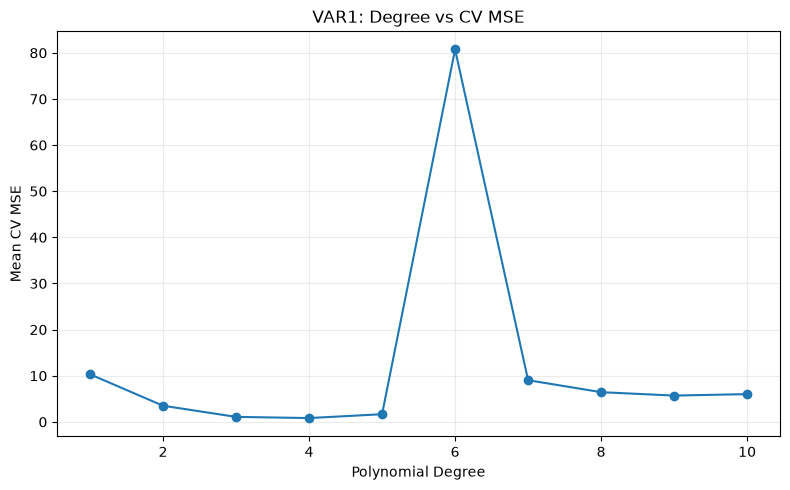

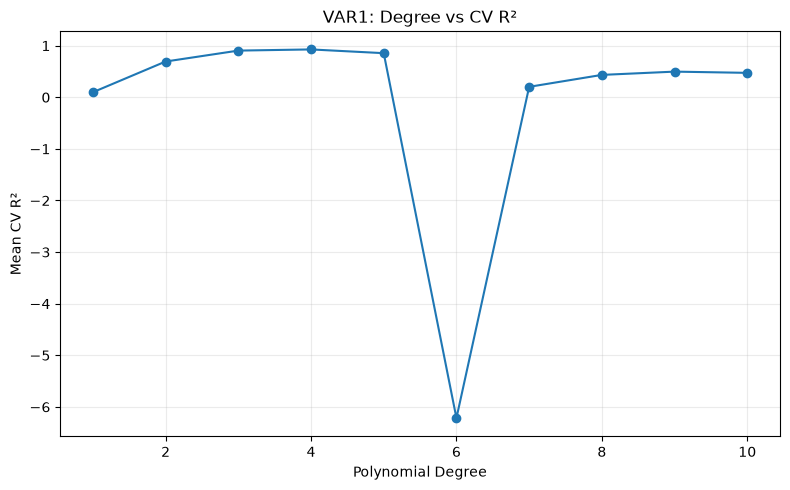

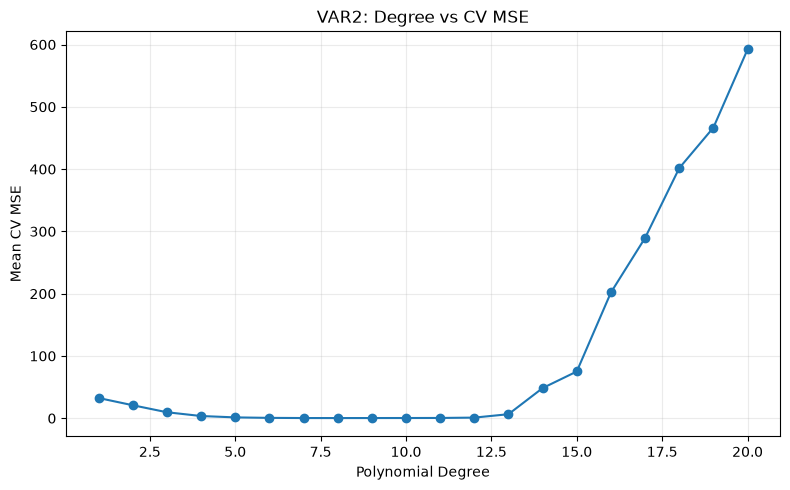

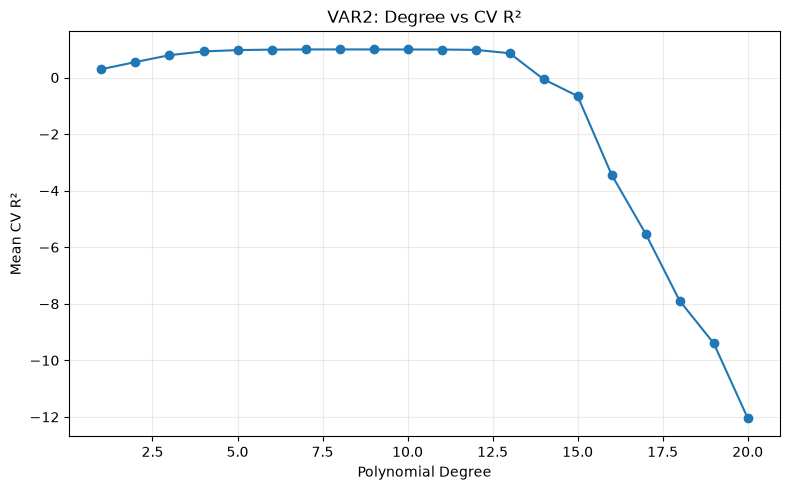

In [13]:
# 11. Degree plots

def degree_plots(results, problem):
    r = results[results["Problem"] == problem].sort_values("Degree")

    plt.figure(figsize=(8,5))
    plt.plot(r["Degree"], r["CV MSE"], marker="o")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Mean CV MSE")
    plt.title(f"{problem}: Degree vs CV MSE")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{problem.lower()}_degree_mse.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(r["Degree"], r["CV R2"], marker="o")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Mean CV R²")
    plt.title(f"{problem}: Degree vs CV R²")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

degree_plots(plain_results, "VAR1")
degree_plots(plain_results, "VAR2")

## 6. Feature subset search

In [14]:
# 12. Feature subset search

def all_subsets(columns):
    result = []
    for r in range(1, len(columns)+1):
        result.extend(combinations(columns, r))
    return result

def subset_search(X, y, problem, max_degree):
    subsets = all_subsets(list(X.columns))
    rows = []
    total = len(subsets) * max_degree
    done = 0

    print(f"{problem}: {len(subsets)} subsets x {max_degree} degrees = {total} CV evaluations")

    for subset in subsets:
        subset = list(subset)
        for degree in range(1, max_degree+1):
            scores = evaluate_cv(make_poly_model(degree), X[subset], y)
            rows.append({
                "Problem": problem,
                "Degree": degree,
                "Features": ", ".join(subset),
                "Feature Count": len(subset),
                **scores
            })
            done += 1
            if done % 50 == 0 or done == total:
                print(f"Completed {done}/{total}")

    return pd.DataFrame(rows)

subset_var1 = subset_search(X_train_var1, y_train_var1, "VAR1", 5)
subset_var2 = subset_search(X_train_var2, y_train_var2, "VAR2", 8)
subset_results = pd.concat([subset_var1, subset_var2], ignore_index=True)

print("Best VAR1 subset models:")
display(subset_var1.sort_values("CV MSE").head(15)[
    ["Degree","Features","Feature Count","CV MSE","CV R2"]
])

print("Best VAR2 subset models:")
display(subset_var2.sort_values("CV MSE").head(15)[
    ["Degree","Features","Feature Count","CV MSE","CV R2"]
])

VAR1: 63 subsets x 5 degrees = 315 CV evaluations
Completed 50/315
Completed 100/315
Completed 150/315
Completed 200/315
Completed 250/315
Completed 300/315
Completed 315/315
VAR2: 7 subsets x 8 degrees = 56 CV evaluations
Completed 50/56
Completed 56/56
Best VAR1 subset models:


,Degree,Features,Feature Count,CV MSE,CV R2
313,4,"x1, x2, x3, x4, x5, x6",6,0.821440,0.926966
312,3,"x1, x2, x3, x4, x5, x6",6,1.079954,0.904228
314,5,"x1, x2, x3, x4, x5, x6",6,1.658359,0.854498
293,4,"x1, x2, x3, x5, x6",5,2.000239,0.822998
292,3,"x1, x2, x3, x5, x6",5,2.098247,0.813910
294,5,"x1, x2, x3, x5, x6",5,2.291553,0.797350
302,3,"x1, x3, x4, x5, x6",5,3.351913,0.703354
303,4,"x1, x3, x4, x5, x6",5,3.400822,0.696388
291,2,"x1, x2, x3, x5, x6",5,3.473552,0.694506
311,2,"x1, x2, x3, x4, x5, x6",6,3.496019,0.692644


Best VAR2 subset models:


,Degree,Features,Feature Count,CV MSE,CV R2
55,8,"x1, x2, x3",3,0.288839,0.993632
54,7,"x1, x2, x3",3,0.330717,0.992743
53,6,"x1, x2, x3",3,0.595603,0.986869
52,5,"x1, x2, x3",3,1.376654,0.969972
51,4,"x1, x2, x3",3,3.572707,0.922630
50,3,"x1, x2, x3",3,9.633387,0.790881
28,5,"x1, x2",2,17.190289,0.627316
29,6,"x1, x2",2,17.250816,0.625778
30,7,"x1, x2",2,17.350372,0.623475
27,4,"x1, x2",2,17.633146,0.619330


## 7. Overfitting check

In [15]:
# 13. Overfitting check

def overfit_table(results, problem):
    r = results[results["Problem"] == problem].copy()
    r["MSE gap"] = r["CV MSE"] - r["Train MSE"]
    r["R2 gap"] = r["Train R2"] - r["CV R2"]
    return r[[
        "Degree","Feature Count","Train MSE","CV MSE","MSE gap",
        "Train R2","CV R2","R2 gap"
    ]].sort_values("Degree")

display(overfit_table(plain_results, "VAR1"))
display(overfit_table(plain_results, "VAR2"))

best_plain_all_var1 = plain_var1.sort_values("CV MSE").iloc[0]
best_plain_all_var2 = plain_var2.sort_values("CV MSE").iloc[0]
best_plain_subset_var1 = subset_var1.sort_values("CV MSE").iloc[0]
best_plain_subset_var2 = subset_var2.sort_values("CV MSE").iloc[0]

print("Best all-feature VAR1:")
display(best_plain_all_var1.to_frame().T)
print("Best subset VAR1:")
display(best_plain_subset_var1.to_frame().T)
print("Best all-feature VAR2:")
display(best_plain_all_var2.to_frame().T)
print("Best subset VAR2:")
display(best_plain_subset_var2.to_frame().T)

,Degree,Feature Count,Train MSE,CV MSE,MSE gap,Train R2,CV R2,R2 gap
0,1,6,10.053566,10.312539,0.258973,0.125891,0.097328,0.028563
1,2,6,3.248119,3.496019,0.247900,0.717507,0.692644,0.024863
2,3,6,0.829852,1.079954,0.250101,0.927790,0.904228,0.023563
3,4,6,0.370311,0.821440,0.451129,0.967777,0.926966,0.040811
4,5,6,0.118501,1.658359,1.539858,0.989692,0.854498,0.135194
5,6,6,0.000861,80.741393,80.740533,0.999924,-6.216301,7.216225
6,7,6,0.000861,9.029460,9.028599,0.999924,0.202202,0.797723
7,8,6,0.000861,6.435328,6.434468,0.999924,0.433417,0.566507
8,9,6,0.000861,5.694630,5.693770,0.999924,0.496833,0.503092
9,10,6,0.000861,6.012948,6.012087,0.999924,0.473040,0.526885


,Degree,Feature Count,Train MSE,CV MSE,MSE gap,Train R2,CV R2,R2 gap
10,1,3,32.187491,32.488301,0.300810,0.304672,0.295672,0.009000
11,2,3,20.019330,20.879367,0.860036,0.567535,0.547756,0.019779
12,3,3,9.067578,9.633387,0.565809,0.804110,0.790881,0.013229
13,4,3,3.101971,3.572707,0.470737,0.933005,0.922630,0.010375
14,5,3,1.145241,1.376654,0.231413,0.975249,0.969972,0.005277
15,6,3,0.436891,0.595603,0.158712,0.990549,0.986869,0.003680
16,7,3,0.223626,0.330717,0.107091,0.995163,0.992743,0.002420
17,8,3,0.166786,0.288839,0.122053,0.996393,0.993632,0.002760
18,9,3,0.147181,0.328232,0.181051,0.996815,0.992694,0.004121
19,10,3,0.129426,0.372207,0.242781,0.997199,0.991775,0.005425


Best all-feature VAR1:


,Problem,Degree,Features,Feature Count,CV MSE,CV MSE std,CV R2,CV R2 std,Train MSE,Train R2
3,VAR1,4,all,6,0.821440,0.110140,0.926966,0.015187,0.370311,0.967777


Best subset VAR1:


,Problem,Degree,Features,Feature Count,CV MSE,CV MSE std,CV R2,CV R2 std,Train MSE,Train R2
313,VAR1,4,"x1, x2, x3, x4, x5, x6",6,0.821440,0.110140,0.926966,0.015187,0.370311,0.967777


Best all-feature VAR2:


,Problem,Degree,Features,Feature Count,CV MSE,CV MSE std,CV R2,CV R2 std,Train MSE,Train R2
7,VAR2,8,all,3,0.288839,0.053908,0.993632,0.001550,0.166786,0.996393


Best subset VAR2:


,Problem,Degree,Features,Feature Count,CV MSE,CV MSE std,CV R2,CV R2 std,Train MSE,Train R2
55,VAR2,8,"x1, x2, x3",3,0.288839,0.053908,0.993632,0.001550,0.166786,0.996393


## 8. Ridge and Lasso

In [16]:
# 14. Regularization setup

RIDGE_ALPHAS = [0.001, 0.01, 0.1, 0.3, 1, 3, 10]
LASSO_ALPHAS = [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1]

REG_DEGREES_VAR1 = [3, 4, 5, 6]
REG_DEGREES_VAR2 = [7, 8, 9, 10, 11]

# Use the strongest ordinary-polynomial feature subset found earlier.
best_plain_subset_var1 = subset_var1.sort_values("CV MSE").iloc[0]
best_plain_subset_var2 = subset_var2.sort_values("CV MSE").iloc[0]

best_features_var1 = best_plain_subset_var1["Features"].split(", ")
best_features_var2 = best_plain_subset_var2["Features"].split(", ")

print("VAR1 regularization degrees:", REG_DEGREES_VAR1)
print("VAR2 regularization degrees:", REG_DEGREES_VAR2)
print("VAR1 features used:", best_features_var1)
print("VAR2 features used:", best_features_var2)
print("Ridge alphas:", RIDGE_ALPHAS)
print("Lasso alphas:", LASSO_ALPHAS)


VAR1 regularization degrees: [3, 4, 5, 6]
VAR2 regularization degrees: [7, 8, 9, 10, 11]
VAR1 features used: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
VAR2 features used: ['x1', 'x2', 'x3']
Ridge alphas: [0.001, 0.01, 0.1, 0.3, 1, 3, 10]
Lasso alphas: [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1]


In [ ]:
# 15. Ridge and Lasso search

def safe_cv(model, X, y):
    # error_score=np.nan prevents one unstable Lasso configuration
    # from stopping the complete search.
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "mse": "neg_mean_squared_error",
            "r2": "r2"
        },
        return_train_score=True,
        n_jobs=-1,
        error_score=np.nan
    )

    return {
        "CV MSE": -np.nanmean(scores["test_mse"]),
        "CV MSE std": np.nanstd(scores["test_mse"]),
        "CV R2": np.nanmean(scores["test_r2"]),
        "CV R2 std": np.nanstd(scores["test_r2"]),
        "Train MSE": -np.nanmean(scores["train_mse"]),
        "Train R2": np.nanmean(scores["train_r2"])
    }

def regularized_search(X, y, problem, features, degrees):
    X_use = X[features]
    rows = []

    total = len(degrees) * (len(RIDGE_ALPHAS) + len(LASSO_ALPHAS))
    done = 0

    print(f"{problem}: {total} regularized CV configurations")

    # ---------------- Ridge ----------------
    for degree in degrees:
        for alpha in RIDGE_ALPHAS:
            try:
                model = make_poly_model(
                    degree,
                    Ridge(alpha=alpha)
                )
                scores = safe_cv(model, X_use, y)

                rows.append({
                    "Problem": problem,
                    "Model": "Ridge",
                    "Degree": degree,
                    "Features": ", ".join(features),
                    "Alpha": alpha,
                    "CV MSE": scores["CV MSE"],
                    "CV MSE std": scores["CV MSE std"],
                    "CV R2": scores["CV R2"],
                    "CV R2 std": scores["CV R2 std"],
                    "Train MSE": scores["Train MSE"],
                    "Train R2": scores["Train R2"]
                })
            except Exception as e:
                print(f"Ridge failed: degree={degree}, alpha={alpha}: {e}")
                rows.append({
                    "Problem": problem,
                    "Model": "Ridge",
                    "Degree": degree,
                    "Features": ", ".join(features),
                    "Alpha": alpha,
                    "CV MSE": np.nan,
                    "CV MSE std": np.nan,
                    "CV R2": np.nan,
                    "CV R2 std": np.nan,
                    "Train MSE": np.nan,
                    "Train R2": np.nan
                })
            done += 1

    # ---------------- Lasso ----------------
    for degree in degrees:
        for alpha in LASSO_ALPHAS:
            try:
                model = make_poly_model(
                    degree,
                    Lasso(
                        alpha=alpha,
                        max_iter=100000,
                        tol=1e-4,
                        random_state=RANDOM_STATE
                    )
                )
                scores = safe_cv(model, X_use, y)

                rows.append({
                    "Problem": problem,
                    "Model": "Lasso",
                    "Degree": degree,
                    "Features": ", ".join(features),
                    "Alpha": alpha,
                    "CV MSE": scores["CV MSE"],
                    "CV MSE std": scores["CV MSE std"],
                    "CV R2": scores["CV R2"],
                    "CV R2 std": scores["CV R2 std"],
                    "Train MSE": scores["Train MSE"],
                    "Train R2": scores["Train R2"]
                })
            except Exception as e:
                print(f"Lasso failed: degree={degree}, alpha={alpha}: {e}")
                rows.append({
                    "Problem": problem,
                    "Model": "Lasso",
                    "Degree": degree,
                    "Features": ", ".join(features),
                    "Alpha": alpha,
                    "CV MSE": np.nan,
                    "CV MSE std": np.nan,
                    "CV R2": np.nan,
                    "CV R2 std": np.nan,
                    "Train MSE": np.nan,
                    "Train R2": np.nan
                })
            done += 1

            if done % 10 == 0 or done == total:
                print(f"Completed {done}/{total}")

    return pd.DataFrame(rows)

reg_var1 = regularized_search(
    X_train_var1,
    y_train_var1,
    "VAR1",
    best_features_var1,
    REG_DEGREES_VAR1
)

reg_var2 = regularized_search(
    X_train_var2,
    y_train_var2,
    "VAR2",
    best_features_var2,
    REG_DEGREES_VAR2
)

regularized_results = pd.concat([reg_var1, reg_var2], ignore_index=True)

print("\nBest regularized VAR1 configurations:")
display(
    reg_var1.dropna(subset=["CV MSE"])
    .sort_values(["CV MSE", "CV MSE std", "CV R2"])
    .head(10)
)

print("\nBest regularized VAR2 configurations:")
display(
    reg_var2.dropna(subset=["CV MSE"])
    .sort_values(["CV MSE", "CV MSE std", "CV R2"])
    .head(10)
)


VAR1: 56 regularized CV configurations
Completed 30/56
Completed 40/56


## 9. Model comparison

In [ ]:
# 16. Model comparison

def best_valid_row(df, model_name=None):
    data = df.copy()
    if model_name is not None:
        data = data[data["Model"] == model_name]
    data = data.dropna(subset=["CV MSE"])
    if data.empty:
        raise RuntimeError(f"No valid configurations found for {model_name or 'requested model'}.")
    return data.sort_values(
        ["CV MSE", "CV MSE std", "CV R2"],
        ascending=[True, True, False]
    ).iloc[0]

best_ridge_var1 = best_valid_row(reg_var1, "Ridge")
best_lasso_var1 = best_valid_row(reg_var1, "Lasso")
best_ridge_var2 = best_valid_row(reg_var2, "Ridge")
best_lasso_var2 = best_valid_row(reg_var2, "Lasso")

def candidate_rows(problem, plain_subset, plain_all, ridge, lasso):
    return pd.DataFrame([
        {
            "Problem": problem,
            "Model": "Plain Polynomial",
            "Degree": int(plain_subset["Degree"]),
            "Features": plain_subset["Features"],
            "Alpha": np.nan,
            "CV MSE": plain_subset["CV MSE"],
            "CV MSE std": plain_subset["CV MSE std"],
            "CV R2": plain_subset["CV R2"],
            "Train MSE": plain_subset["Train MSE"],
            "Train R2": plain_subset["Train R2"]
        },
        {
            "Problem": problem,
            "Model": "Plain Polynomial",
            "Degree": int(plain_all["Degree"]),
            "Features": "all",
            "Alpha": np.nan,
            "CV MSE": plain_all["CV MSE"],
            "CV MSE std": plain_all["CV MSE std"],
            "CV R2": plain_all["CV R2"],
            "Train MSE": plain_all["Train MSE"],
            "Train R2": plain_all["Train R2"]
        },
        {
            "Problem": problem,
            "Model": "Ridge",
            "Degree": int(ridge["Degree"]),
            "Features": ridge["Features"],
            "Alpha": ridge["Alpha"],
            "CV MSE": ridge["CV MSE"],
            "CV MSE std": ridge["CV MSE std"],
            "CV R2": ridge["CV R2"],
            "Train MSE": ridge["Train MSE"],
            "Train R2": ridge["Train R2"]
        },
        {
            "Problem": problem,
            "Model": "Lasso",
            "Degree": int(lasso["Degree"]),
            "Features": lasso["Features"],
            "Alpha": lasso["Alpha"],
            "CV MSE": lasso["CV MSE"],
            "CV MSE std": lasso["CV MSE std"],
            "CV R2": lasso["CV R2"],
            "Train MSE": lasso["Train MSE"],
            "Train R2": lasso["Train R2"]
        }
    ])

comparison_var1 = candidate_rows(
    "VAR1",
    best_plain_subset_var1,
    best_plain_all_var1,
    best_ridge_var1,
    best_lasso_var1
)

comparison_var2 = candidate_rows(
    "VAR2",
    best_plain_subset_var2,
    best_plain_all_var2,
    best_ridge_var2,
    best_lasso_var2
)

comparison_table = pd.concat(
    [comparison_var1, comparison_var2],
    ignore_index=True
)

display(comparison_table)

print("\nBest candidate by CV MSE:")
display(
    comparison_table.sort_values(
        ["Problem", "CV MSE", "CV MSE std", "CV R2"],
        ascending=[True, True, True, False]
    ).groupby("Problem", as_index=False).head(1)
)


,Problem,Model,Degree,Features,Alpha,CV MSE,CV MSE std,CV R2,Train MSE,Train R2
0,VAR1,Plain Polynomial,4,"x1, x2, x3, x4, x5, x6",NaN,0.821440,0.110140,0.926966,0.370311,0.967777
1,VAR1,Plain Polynomial,4,all,NaN,0.821440,0.110140,0.926966,0.370311,0.967777
2,VAR1,Ridge,5,"x1, x2, x3, x4, x5, x6",10.000000,0.519615,0.066753,0.954163,0.166793,0.985493
3,VAR1,Lasso,5,"x1, x2, x3, x4, x5, x6",0.010000,0.360046,0.032353,0.968348,0.240625,0.979069
4,VAR2,Plain Polynomial,8,"x1, x2, x3",NaN,0.288839,0.053908,0.993632,0.166786,0.996393
5,VAR2,Plain Polynomial,8,all,NaN,0.288839,0.053908,0.993632,0.166786,0.996393
6,VAR2,Ridge,11,"x1, x2, x3",1.000000,0.264288,0.042851,0.994164,0.163437,0.996464
7,VAR2,Lasso,11,"x1, x2, x3",0.001000,0.267520,0.041728,0.994102,0.173575,0.996245



Best candidate by CV MSE:


,Problem,Model,Degree,Features,Alpha,CV MSE,CV MSE std,CV R2,Train MSE,Train R2
3,VAR1,Lasso,5,"x1, x2, x3, x4, x5, x6",0.010000,0.360046,0.032353,0.968348,0.240625,0.979069
6,VAR2,Ridge,11,"x1, x2, x3",1.000000,0.264288,0.042851,0.994164,0.163437,0.996464


In [ ]:
# 17. Final model selection

def select_final(comparison):
    valid = comparison.dropna(subset=["CV MSE"]).copy()

    # Primary criterion: lowest CV MSE.
    # Tie-breakers: lower CV MSE variation, then higher CV R2.
    return valid.sort_values(
        ["CV MSE", "CV MSE std", "CV R2"],
        ascending=[True, True, False]
    ).iloc[0]

final_config_var1 = select_final(comparison_var1)
final_config_var2 = select_final(comparison_var2)

print("FINAL VAR1 CONFIGURATION")
display(final_config_var1.to_frame().T)

print("FINAL VAR2 CONFIGURATION")
display(final_config_var2.to_frame().T)


FINAL VAR1 CONFIGURATION


,Problem,Model,Degree,Features,Alpha,CV MSE,CV MSE std,CV R2,Train MSE,Train R2
3,VAR1,Lasso,5,"x1, x2, x3, x4, x5, x6",0.010000,0.360046,0.032353,0.968348,0.240625,0.979069


FINAL VAR2 CONFIGURATION


,Problem,Model,Degree,Features,Alpha,CV MSE,CV MSE std,CV R2,Train MSE,Train R2
2,VAR2,Ridge,11,"x1, x2, x3",1.000000,0.264288,0.042851,0.994164,0.163437,0.996464


## 10. Final models

In [ ]:
# 18. Fit final models

def build_from_config(config):
    degree = int(config["Degree"])

    if config["Features"] == "all":
        features = None
    else:
        features = [f.strip() for f in str(config["Features"]).split(",")]

    if config["Model"] == "Plain Polynomial":
        estimator = LinearRegression()

    elif config["Model"] == "Ridge":
        estimator = Ridge(alpha=float(config["Alpha"]))

    elif config["Model"] == "Lasso":
        estimator = Lasso(
            alpha=float(config["Alpha"]),
            max_iter=100000,
            tol=1e-4,
            random_state=RANDOM_STATE
        )

    else:
        raise ValueError(f"Unknown final model: {config['Model']}")

    return make_poly_model(degree, estimator), features

final_model_var1, final_features_var1 = build_from_config(final_config_var1)
final_model_var2, final_features_var2 = build_from_config(final_config_var2)

X_fit_var1 = (
    X_train_var1
    if final_features_var1 is None
    else X_train_var1[final_features_var1]
)

X_fit_var2 = (
    X_train_var2
    if final_features_var2 is None
    else X_train_var2[final_features_var2]
)

# Fit ONLY on the complete training sets.
final_model_var1.fit(X_fit_var1, y_train_var1)
final_model_var2.fit(X_fit_var2, y_train_var2)

print("Final models fitted successfully.")
print("VAR1 model   :", final_config_var1["Model"])
print("VAR1 degree  :", int(final_config_var1["Degree"]))
print("VAR1 features:", list(X_fit_var1.columns))

print("\nVAR2 model   :", final_config_var2["Model"])
print("VAR2 degree  :", int(final_config_var2["Degree"]))
print("VAR2 features:", list(X_fit_var2.columns))


Final models fitted successfully.
VAR1 model   : Lasso
VAR1 degree  : 5
VAR1 features: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

VAR2 model   : Ridge
VAR2 degree  : 11
VAR2 features: ['x1', 'x2', 'x3']


## 11. Training diagnostics

In [ ]:
# 19. Training diagnostics

def diagnostics(model, X, y, problem):
    pred = model.predict(X)
    residuals = y.to_numpy() - pred
    return {
        "Problem": problem,
        "Training MSE": mean_squared_error(y, pred),
        "Training RMSE": np.sqrt(mean_squared_error(y, pred)),
        "Training R2": r2_score(y, pred),
        "Residual mean": residuals.mean(),
        "Residual median": np.median(residuals),
        "Residual minimum": residuals.min(),
        "Residual maximum": residuals.max()
    }, pred, residuals

diag_var1, train_pred_var1, residuals_var1 = diagnostics(
    final_model_var1, X_fit_var1, y_train_var1, "VAR1"
)
diag_var2, train_pred_var2, residuals_var2 = diagnostics(
    final_model_var2, X_fit_var2, y_train_var2, "VAR2"
)

diagnostics_table = pd.DataFrame([diag_var1, diag_var2])
display(diagnostics_table)

,Problem,Training MSE,Training RMSE,Training R2,Residual mean,Residual median,Residual minimum,Residual maximum
0,VAR1,0.252470,0.502463,0.978058,0.000000,0.000615,-1.367350,1.801755
1,VAR2,0.170073,0.412400,0.996327,0.000000,-0.002513,-1.291638,1.476786


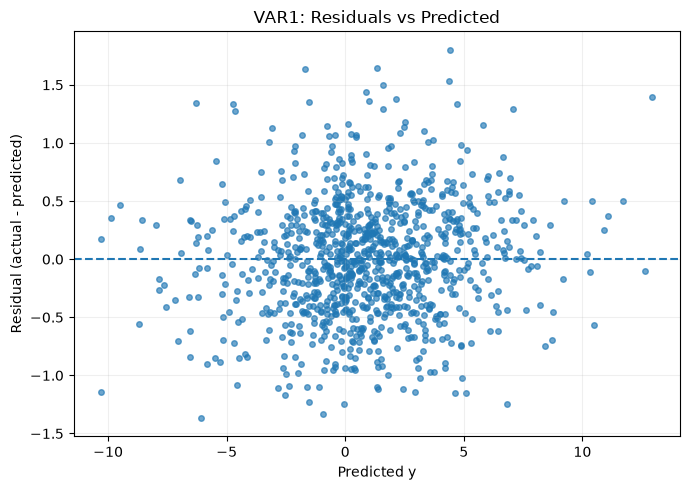

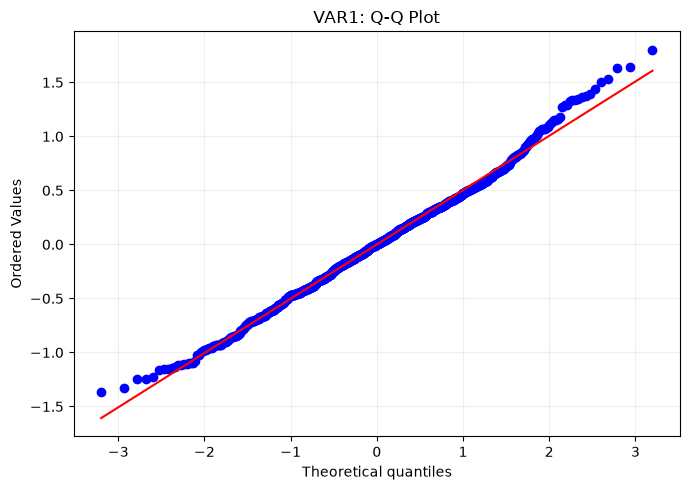

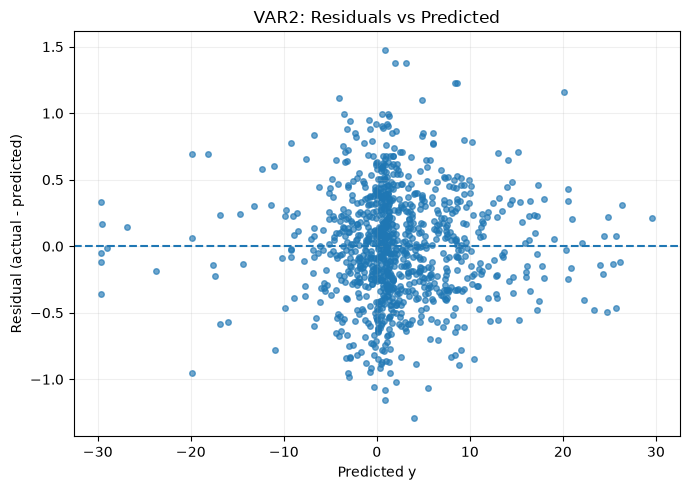

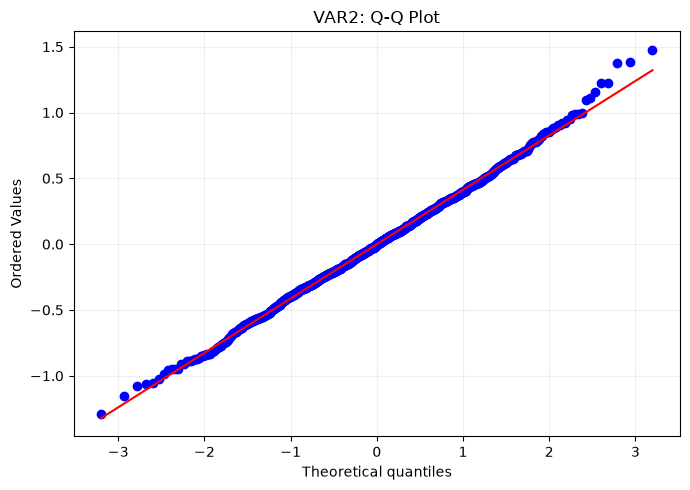

In [ ]:
# 20. Diagnostic plots

def diagnostic_plots(y, pred, residuals, problem):
    plt.figure(figsize=(7,5))
    plt.scatter(pred, residuals, s=16, alpha=0.65)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted y")
    plt.ylabel("Residual (actual - predicted)")
    plt.title(f"{problem}: Residuals vs Predicted")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{problem.lower()}_residuals.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(7,5))
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{problem}: Q-Q Plot")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{problem.lower()}_qq.png", dpi=150)
    plt.show()

diagnostic_plots(y_train_var1, train_pred_var1, residuals_var1, "VAR1")
diagnostic_plots(y_train_var2, train_pred_var2, residuals_var2, "VAR2")

## 12. Test predictions

In [ ]:
# 21. Test predictions

X_final_test_var1 = X_test_var1 if final_features_var1 is None else X_test_var1[final_features_var1]
X_final_test_var2 = X_test_var2 if final_features_var2 is None else X_test_var2[final_features_var2]

y_test_pred_var1 = final_model_var1.predict(X_final_test_var1)
y_test_pred_var2 = final_model_var2.predict(X_final_test_var2)

def prediction_summary(pred, problem):
    print(f"\n{problem}")
    print("Shape :", pred.shape)
    print("First 5:", pred[:5])
    print("Min   :", pred.min())
    print("Max   :", pred.max())
    print("Mean  :", pred.mean())

prediction_summary(y_test_pred_var1, "VAR1")
prediction_summary(y_test_pred_var2, "VAR2")


VAR1
Shape : (1000,)
First 5: [-4.49454454  0.52452906  0.92375768 -0.41420986 -0.24054549]
Min   : -10.606248784885647
Max   : 16.12131940042161
Mean  : 1.094889691621536

VAR2
Shape : (1000,)
First 5: [ 1.04164932  6.82851499  1.29901446  1.34020262 14.16018251]
Min   : -29.753085437110144
Max   : 37.072225679817514
Mean  : 2.4635658294367895


## 13. Prediction files

In [ ]:
# 22. Save predictions

submission_var1 = pd.DataFrame({"y": y_test_pred_var1})
submission_var2 = pd.DataFrame({"y": y_test_pred_var2})

pred_var1_path = OUTPUT_DIR / f"{ROLL_NO}_pred_var1.csv"
pred_var2_path = OUTPUT_DIR / f"{ROLL_NO}_pred_var2.csv"

submission_var1.to_csv(pred_var1_path, index=False)
submission_var2.to_csv(pred_var2_path, index=False)

print("Saved:")
print(pred_var1_path)
print(pred_var2_path)

Saved:
C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026\outputs\IMT2023608_pred_var1.csv
C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026\outputs\IMT2023608_pred_var2.csv


In [ ]:
# 23. Validate submissions

def validate_submission(path, expected_rows):
    checks = {}
    checks["file exists"] = path.exists()

    if not checks["file exists"]:
        return checks

    df = pd.read_csv(path)
    checks["correct number of rows"] = len(df) == expected_rows
    checks["correct number of columns"] = df.shape[1] == 1
    checks["correct column name"] = list(df.columns) == ["y"]
    checks["no missing values"] = not df["y"].isna().any()
    checks["all values numeric"] = pd.api.types.is_numeric_dtype(df["y"])
    checks["all values finite"] = np.isfinite(df["y"].to_numpy()).all()
    checks["no accidental index column"] = "Unnamed: 0" not in df.columns
    checks["prediction count equals test rows"] = len(df) == expected_rows
    return checks

def print_validation(name, checks):
    passed = all(checks.values())
    print(f"{name} validation: {'PASSED' if passed else 'FAILED'}")
    for key, value in checks.items():
        print(f"  [{'OK' if value else 'FAIL'}] {key}")
    return passed

validation_var1 = validate_submission(pred_var1_path, len(test_var1))
validation_var2 = validate_submission(pred_var2_path, len(test_var2))

valid1 = print_validation("VAR1", validation_var1)
valid2 = print_validation("VAR2", validation_var2)

if valid1 and valid2:
    print("\nAll submission validation checks passed.")
else:
    print("\nSubmission validation FAILED. Fix the failed checks before submission.")

VAR1 validation: PASSED
  [OK] file exists
  [OK] correct number of rows
  [OK] correct number of columns
  [OK] correct column name
  [OK] no missing values
  [OK] all values numeric
  [OK] all values finite
  [OK] no accidental index column
  [OK] prediction count equals test rows
VAR2 validation: PASSED
  [OK] file exists
  [OK] correct number of rows
  [OK] correct number of columns
  [OK] correct column name
  [OK] no missing values
  [OK] all values numeric
  [OK] all values finite
  [OK] no accidental index column
  [OK] prediction count equals test rows

All submission validation checks passed.


## 14. Save results

In [ ]:
# 24. Save results

plain_results.to_csv(OUTPUT_DIR / "plain_polynomial_results.csv", index=False)
subset_results.to_csv(OUTPUT_DIR / "feature_subset_results.csv", index=False)
regularized_results.to_csv(OUTPUT_DIR / "regularized_results.csv", index=False)
comparison_table.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
diagnostics_table.to_csv(OUTPUT_DIR / "training_diagnostics.csv", index=False)

final_config_table = pd.DataFrame([final_config_var1, final_config_var2])
final_config_table.to_csv(OUTPUT_DIR / "final_model_configuration.csv", index=False)

print("Saved experiment tables to:", OUTPUT_DIR)

Saved experiment tables to: C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026\outputs


# 15. Final summary

Use these values in the report. Test labels are unavailable.

In [ ]:
# 25. Final summary

def print_final(problem, config):
    print(f"\n{'='*65}")
    print(problem)
    print(f"{'='*65}")
    print("Model       :", config["Model"])
    print("Degree      :", int(config["Degree"]))
    print("Features    :", config["Features"])
    print("Alpha       :", config["Alpha"])
    print("CV MSE      :", config["CV MSE"])
    print("CV R²       :", config["CV R2"])
    print("CV MSE std  :", config["CV MSE std"])

print_final("VAR1 FINAL MODEL", final_config_var1)
print_final("VAR2 FINAL MODEL", final_config_var2)

print("\nPrediction files:")
print(pred_var1_path.name, "->", len(y_test_pred_var1), "predictions")
print(pred_var2_path.name, "->", len(y_test_pred_var2), "predictions")

print("\nValidation status:")
print("VAR1:", "PASSED" if valid1 else "FAILED")
print("VAR2:", "PASSED" if valid2 else "FAILED")

if valid1 and valid2:
    print("\nAll submission validation checks passed.")
else:
    print("\nSubmission validation FAILED.")



VAR1 FINAL MODEL
Model       : Lasso
Degree      : 5
Features    : x1, x2, x3, x4, x5, x6
Alpha       : 0.01
CV MSE      : 0.360046038447016
CV R²       : 0.9683477576155232
CV MSE std  : 0.032353112750979275

VAR2 FINAL MODEL
Model       : Ridge
Degree      : 11
Features    : x1, x2, x3
Alpha       : 1.0
CV MSE      : 0.2642882842200106
CV R²       : 0.994163851625045
CV MSE std  : 0.04285133231271398

Prediction files:
IMT2023608_pred_var1.csv -> 1000 predictions
IMT2023608_pred_var2.csv -> 1000 predictions

Validation status:
VAR1: PASSED
VAR2: PASSED

All submission validation checks passed.


# Final audit

In [ ]:
print("Python executable:", sys.executable)
print("Dataset directory:", DATA_DIR)
print("Dataset directory exists:", DATA_DIR.exists())
print("Output directory:", OUTPUT_DIR)
print("VAR1 prediction file:", pred_var1_path)
print("VAR2 prediction file:", pred_var2_path)

assert DATA_DIR.exists(), "Dataset directory does not exist."
assert pred_var1_path.parent == OUTPUT_DIR
assert pred_var2_path.parent == OUTPUT_DIR
assert pred_var1_path.exists(), "VAR1 prediction file was not created."
assert pred_var2_path.exists(), "VAR2 prediction file was not created."

print("\nFINAL AUDIT: PASSED")

Python executable: c:\Users\kvina\AppData\Local\Programs\Python\Python313\python.exe
Dataset directory: C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026
Dataset directory exists: True
Output directory: C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026\outputs
VAR1 prediction file: C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026\outputs\IMT2023608_pred_var1.csv
VAR2 prediction file: C:\Users\kvina\Downloads\ML_Assignment\OneDrive_1_10-7-2026\outputs\IMT2023608_pred_var2.csv

FINAL AUDIT: PASSED
